#### Libraries + Configuration

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
from scipy import stats
from itertools import combinations
import matplotlib
from matplotlib import rcParams

# ── Output directory
OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Font settings
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Global style
rcParams.update({
    "figure.facecolor" : "#1B2A4A",   # Navy background
    "axes.facecolor"   : "#243558",   # Plot area
    "axes.edgecolor"   : "#4A6080",
    "axes.labelcolor"  : "#FFFFFF",   # White
    "axes.titlecolor"  : "#FFFFFF",   # White
    "xtick.color"      : "#FFFFFF",   # White
    "ytick.color"      : "#FFFFFF",   # White
    "text.color"       : "#FFFFFF",   # White
    "grid.color"       : "#4A6080",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor" : "#4A6080",
    "legend.facecolor" : "#1B2A4A",
})

# ── Colors
C_GOOD, C_BAD = "#1D9E75", "#C44E52"
C_BEFORE, C_DURING, C_AFTER = "#4C72B0", "#888780", "#C44E52"

# Keep original Korean category values for data processing
TIMING_COLORS = {
    "장전": C_BEFORE,
    "장중": C_DURING,
    "장후": C_AFTER
}

# English labels for visualization
TIMING_LABELS = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours"
}

NEWS_LABELS = {
    "호재": "Good News",
    "악재": "Bad News"
}

#### Data Preprocessing

In [2]:
DATA_DIR = Path("../data_collection")

raw_fin  = pd.read_csv(DATA_DIR / "dart_earnings_financials_2019_2026.csv", dtype=str)
raw_ctrl = pd.read_csv(DATA_DIR / "dart_financial_controls_2019_2025.csv")
raw_comp = pd.read_csv(DATA_DIR / "company_krx_fdr_controls_2019_2026.csv")

print(f"Disclosure data: {len(raw_fin):,} rows")

Disclosure data: 16,218 rows


In [3]:
# Filtering
remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly", na=False, regex=True
)
fin = raw_fin[~remove].copy()
fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()

# Remove duplicates, prioritizing consolidated disclosures
fin["is_consolidated"] = fin["report_nm"].str.contains("연결", na=False)
fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)
fin = fin.drop_duplicates(subset=["stock_code", "rcept_dt"], keep="first")

# Classify disclosure timing
t = fin["rcept_time"].str.split(":", expand=True)
fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")
fin["timing"] = "Intraday"
fin.loc[fin["_h"] < 9, "timing"] = "Pre-market"
fin.loc[(fin["_h"] > 15) | ((fin["_h"] == 15) & (fin["_m"] > 30)), "timing"] = "After-hours"
fin.loc[fin["_h"].isna(), "timing"] = None
fin.drop(columns=["_h", "_m"], inplace=True)
fin["rcept_dt_dt"] = pd.to_datetime(fin["rcept_dt"], format="%Y%m%d")
fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek

# Classify good and bad news
fin["oi_won"] = pd.to_numeric(fin["operating_income_won"], errors="coerce")
fin = fin.sort_values(["stock_code", "rcept_dt_dt"])
fin["prev_oi"] = fin.groupby("stock_code")["oi_won"].shift(1)
fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna() & (fin["prev_oi"] != 0),
    (fin["oi_won"] - fin["prev_oi"]) / fin["prev_oi"].abs(),
    np.nan
)
fin["news"] = np.select(
    [fin["oi_chg_pct"] > 0.10, fin["oi_chg_pct"] < -0.10,
     fin["oi_chg_pct"].between(-0.10, 0.10, inclusive="both")],
    ["Good News", "Bad News", "Neutral"], default="Missing"
)

df = fin.copy()
df_hb = df[df["news"].isin(["Good News", "Bad News"]) & df["timing"].notna()].copy()

print(f"Final sample: {len(df):,} observations")
print(f"Good News: {df['news'].eq('Good News').sum():,}  Bad News: {df['news'].eq('Bad News').sum():,}")
print(f"Timing: {df['timing'].value_counts().to_dict()}")

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030
Timing: {'Intraday': 6362, 'After-hours': 5118, 'Pre-market': 811}


### 3-1. Two-Stage Regression Analysis: Stage 1 Logistic Regression (Timing Choice Model) + Stage 2 OLS Regression

=== Regression Sample Check ===
Observations: 7,978

Timing distribution:
timing
Intraday       4354
After-hours    3624
Name: count, dtype: int64

News distribution:
news
Good News    4197
Bad News     3781
Name: count, dtype: int64

=== Stage 1 Data Check ===
Sample size: 7,978
After-hours observations: 3,624
Intraday observations: 4,354

=== 3-1. Stage 1: After-Hours Disclosure Choice Logistic Regression ===
Sample size: 7,978
After-hours disclosure share: 45.4%
In-sample classification accuracy (0.5 threshold): 75.0%
Robust covariance: HC3
Odds ratios are based on standardized predictors (one-standard-deviation changes).
        Variable  Coefficient  Odds Ratio  OR 95% CI Low  OR 95% CI High  p-value
       bad_dummy       0.2402       1.272          1.205           1.342   0.0000
    bad_severity       0.1330       1.142          0.978           1.334   0.0926
       is_kosdaq      -0.0376       0.963          0.908           1.021   0.2067
      log_marcap      -0.1732       0.8

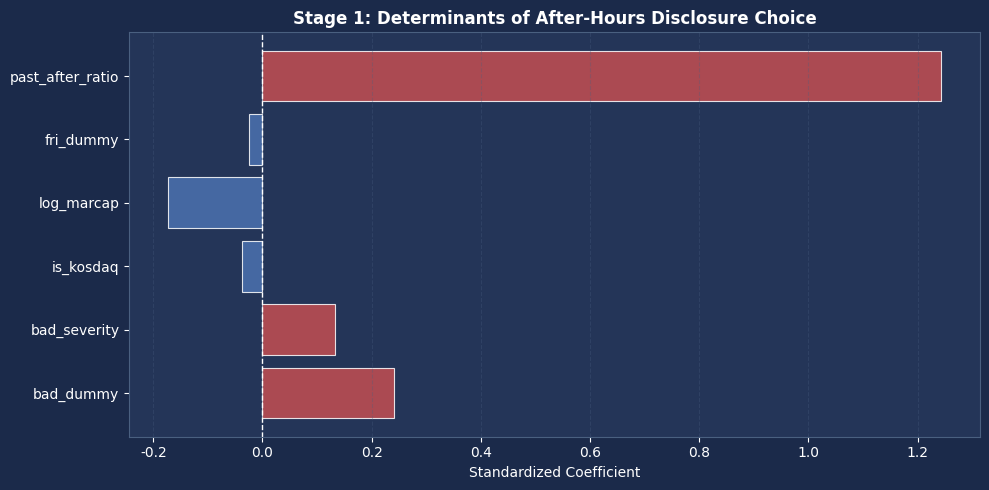

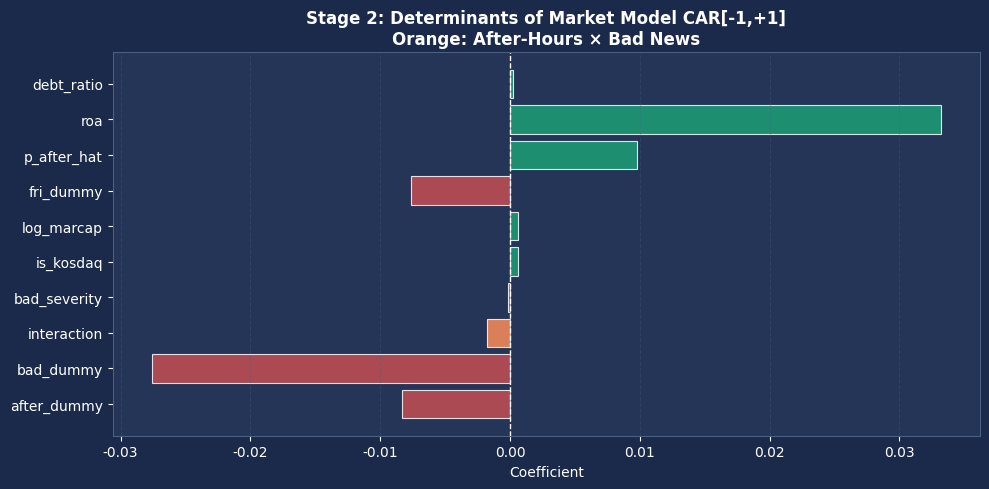


Files saved:
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\03_1_logit_market_model.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\03_2_ols_market_model.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\regression_analysis_dataset.csv
Number of rows saved: 7,978


In [4]:
# ============================================================
# 3. Two-Stage Regression Analysis
# - Stage 1: Logistic Regression for After-Hours Disclosure Choice
# - CAR Calculation: Market Model
# - Stage 2: OLS Regression for CAR
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf


# ------------------------------------------------------------
# 0. Load Price and Market Data
# ------------------------------------------------------------

price_df = pd.read_csv(
    DATA_DIR / "stock_price_2018_2026.csv",
    low_memory=False
)

market_df = pd.read_csv(
    DATA_DIR / "market_index_2018_2026.csv"
)

price_df["date"] = pd.to_datetime(price_df["date"])
market_df["date"] = pd.to_datetime(market_df["date"])

price_df["stock_code"] = (
    price_df["stock_code"]
    .astype(str)
    .str.zfill(6)
)


# ------------------------------------------------------------
# 1. Construct Regression Dataset
# ------------------------------------------------------------

# Keep only Intraday and After-hours disclosures
reg_df = df_hb[
    df_hb["timing"].isin(["Intraday", "After-hours"])
].copy()

reg_df["stock_code"] = (
    reg_df["stock_code"]
    .astype(str)
    .str.zfill(6)
)

reg_df["rcept_dt"] = reg_df["rcept_dt"].astype(str)

reg_df["rcept_dt_dt"] = pd.to_datetime(
    reg_df["rcept_dt"],
    format="%Y%m%d"
)

# Binary variables
reg_df["after_dummy"] = (
    reg_df["timing"] == "After-hours"
).astype(int)

reg_df["bad_dummy"] = (
    reg_df["news"] == "Bad News"
).astype(int)

# Severity of bad news
reg_df["bad_severity"] = np.where(
    reg_df["oi_chg_pct"] < -0.10,
    reg_df["oi_chg_pct"].abs(),
    0
)

# Friday dummy
reg_df["fri_dummy"] = (
    reg_df["weekday"] == 4
).astype(int)


print("=== Regression Sample Check ===")
print(f"Observations: {len(reg_df):,}")
print("\nTiming distribution:")
print(reg_df["timing"].value_counts())
print("\nNews distribution:")
print(reg_df["news"].value_counts())


# ------------------------------------------------------------
# 2. Merge KRX Control Variables
# ------------------------------------------------------------

raw_comp2 = raw_comp.copy()

raw_comp2["stock_code"] = (
    raw_comp2["stock_code"]
    .astype(str)
    .str.zfill(6)
)

# KOSDAQ dummy
if "is_kosdaq" not in raw_comp2.columns:
    raw_comp2["is_kosdaq"] = (
        raw_comp2["market"]
        .astype(str)
        .str.upper()
        .str.contains("KOSDAQ|코스닥", na=False)
        .astype(int)
    )

# Log market capitalization
if "log_marcap" not in raw_comp2.columns:

    raw_comp2["marcap"] = pd.to_numeric(
        raw_comp2["marcap"],
        errors="coerce"
    )

    raw_comp2["log_marcap"] = np.log(
        raw_comp2["marcap"]
    )


reg_df = reg_df.merge(
    raw_comp2[
        [
            "stock_code",
            "is_kosdaq",
            "log_marcap"
        ]
    ].drop_duplicates("stock_code"),
    on="stock_code",
    how="left"
)


# ------------------------------------------------------------
# 3. Merge Financial Control Variables
# ------------------------------------------------------------

raw_ctrl2 = raw_ctrl.copy()

raw_ctrl2["stock_code"] = (
    raw_ctrl2["stock_code"]
    .astype(str)
    .str.zfill(6)
)

raw_ctrl2["year"] = pd.to_numeric(
    raw_ctrl2["year"],
    errors="coerce"
)

reg_df["year"] = pd.to_numeric(
    reg_df["year"],
    errors="coerce"
)


reg_df = reg_df.merge(
    raw_ctrl2[
        [
            "stock_code",
            "year",
            "roa",
            "debt_ratio"
        ]
    ].drop_duplicates(
        ["stock_code", "year"]
    ),
    on=["stock_code", "year"],
    how="left"
)


# Convert control variables to numeric
numeric_cols = [
    "is_kosdaq",
    "log_marcap",
    "roa",
    "debt_ratio",
    "bad_severity"
]

for c in numeric_cols:
    reg_df[c] = pd.to_numeric(
        reg_df[c],
        errors="coerce"
    )


# Handle missing values
reg_df["is_kosdaq"] = (
    reg_df["is_kosdaq"]
    .fillna(0)
)

reg_df["log_marcap"] = (
    reg_df["log_marcap"]
    .fillna(
        reg_df["log_marcap"].median()
    )
)

reg_df["roa"] = (
    reg_df["roa"]
    .fillna(
        reg_df["roa"].median()
    )
)

reg_df["debt_ratio"] = (
    reg_df["debt_ratio"]
    .fillna(
        reg_df["debt_ratio"].median()
    )
)

reg_df["bad_severity"] = (
    reg_df["bad_severity"]
    .fillna(0)
)


# ------------------------------------------------------------
# 4. Historical After-Hours Disclosure Ratio
#    Strictly prior events only (no temporal leakage)
# ------------------------------------------------------------
# IMPORTANT:
# past_after_ratio must use only information available BEFORE the
# focal disclosure. A leave-one-out ratio based on the full sample
# would include future disclosures and therefore create temporal leakage.

sort_cols = ["stock_code", "rcept_dt_dt"]

# Use filing time when available so multiple disclosures on the same
# calendar date are ordered as precisely as possible.
if "rcept_time" in reg_df.columns:
    sort_cols.append("rcept_time")

# Receipt number provides a stable tie-breaker when available.
if "rcept_no" in reg_df.columns:
    sort_cols.append("rcept_no")

reg_df = reg_df.sort_values(
    sort_cols,
    kind="mergesort"
).copy()

# Number of prior after-hours disclosures for each focal event
prior_after_count = (
    reg_df.groupby("stock_code")["after_dummy"].cumsum()
    - reg_df["after_dummy"]
)

# Number of prior observed disclosures for each focal event
prior_event_count = (
    reg_df.groupby("stock_code").cumcount()
)

# Historical after-hours ratio based strictly on preceding events.
# For the first observed disclosure of a firm, no prior history exists;
# the ratio is coded as 0.0 and this convention is stated in the report.
reg_df["past_after_ratio"] = np.where(
    prior_event_count > 0,
    prior_after_count / prior_event_count,
    0.0
)


# ------------------------------------------------------------
# 5. Stage 1 Logistic Regression
# Determinants of After-Hours Disclosure Choice
# ------------------------------------------------------------

feature_cols = [
    "bad_dummy",
    "bad_severity",
    "is_kosdaq",
    "log_marcap",
    "fri_dummy",
    "past_after_ratio"
]

model_df = reg_df[
    feature_cols + ["after_dummy"]
].dropna().copy()

print("\n=== Stage 1 Data Check ===")
print(f"Sample size: {len(model_df):,}")
print(
    f"After-hours observations: "
    f"{model_df['after_dummy'].sum():,}"
)
print(
    f"Intraday observations: "
    f"{(model_df['after_dummy'] == 0).sum():,}"
)

if len(model_df) == 0:
    raise ValueError(
        "Stage 1 regression sample is empty. "
        "Check timing/news category values and merged variables."
    )

X = model_df[feature_cols].values
y = model_df["after_dummy"].values

# Standardize explanatory variables so coefficients and odds ratios
# are comparable across predictors with different units.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_cols,
    index=model_df.index
)

# Inferential logistic regression with HC3 heteroskedasticity-robust covariance.
# Odds ratios correspond to a one-standard-deviation increase in each
# standardized predictor (binary indicators are standardized as well).
X_logit = sm.add_constant(
    X_scaled_df,
    has_constant="add"
)

logit_model = sm.Logit(
    y,
    X_logit
).fit(
    disp=False,
    cov_type="HC3"
)

# Predicted probability of after-hours disclosure.
# This is used as a control in Stage 2.
reg_df.loc[
    model_df.index,
    "p_after_hat"
] = logit_model.predict(X_logit)

# Coefficient / effect-size table
conf = logit_model.conf_int()

coef_df = pd.DataFrame({
    "Variable": feature_cols,
    "Coefficient": [
        logit_model.params[v]
        for v in feature_cols
    ],
    "Odds Ratio": [
        np.exp(logit_model.params[v])
        for v in feature_cols
    ],
    "OR 95% CI Low": [
        np.exp(conf.loc[v, 0])
        for v in feature_cols
    ],
    "OR 95% CI High": [
        np.exp(conf.loc[v, 1])
        for v in feature_cols
    ],
    "p-value": [
        logit_model.pvalues[v]
        for v in feature_cols
    ]
})

coef_df = coef_df.round({
    "Coefficient": 4,
    "Odds Ratio": 3,
    "OR 95% CI Low": 3,
    "OR 95% CI High": 3,
    "p-value": 4
})

pred_class = (
    logit_model.predict(X_logit) >= 0.5
).astype(int)

accuracy = (
    pred_class == y
).mean()

print(
    "\n=== 3-1. Stage 1: "
    "After-Hours Disclosure Choice Logistic Regression ==="
)

print(
    f"Sample size: "
    f"{len(model_df):,}"
)

print(
    f"After-hours disclosure share: "
    f"{model_df['after_dummy'].mean() * 100:.1f}%"
)

print(
    f"In-sample classification accuracy "
    f"(0.5 threshold): {accuracy * 100:.1f}%"
)

print("Robust covariance: HC3")
print(
    "Odds ratios are based on standardized predictors "
    "(one-standard-deviation changes)."
)

print(
    coef_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 6. Calculate CAR Based on the Market Model
# ------------------------------------------------------------

price_df = (
    price_df
    .sort_values(
        ["stock_code", "date"]
    )
    .copy()
)


price_df["ret"] = pd.to_numeric(
    price_df["change"],
    errors="coerce"
)

market_df["market_ret"] = pd.to_numeric(
    market_df["change"],
    errors="coerce"
)


market_ret = market_df[
    [
        "date",
        "index_type",
        "market_ret"
    ]
].copy()


# Merge market classification by stock
price_df = price_df.merge(
    raw_comp2[
        [
            "stock_code",
            "market"
        ]
    ].drop_duplicates(
        "stock_code"
    ),
    on="stock_code",
    how="left"
)


# Match each stock with KOSPI or KOSDAQ index
price_df["index_type"] = np.where(
    price_df["market"]
    .astype(str)
    .str.upper()
    .str.contains(
        "KOSDAQ",
        na=False
    ),
    "KOSDAQ",
    "KOSPI"
)


price_df = price_df.merge(
    market_ret,
    on=[
        "date",
        "index_type"
    ],
    how="left"
)


price_df = price_df.dropna(
    subset=[
        "ret",
        "market_ret"
    ]
).copy()


# Create stock-level price data dictionary
price_by_stock = {
    code: g.reset_index(
        drop=True
    )
    for code, g
    in price_df.groupby(
        "stock_code"
    )
}


# ------------------------------------------------------------
# Identify Event Trading Day
# ------------------------------------------------------------

def get_event_trading_index(
    stock_data,
    disclosure_date,
    after_dummy
):

    dates = stock_data[
        "date"
    ].values

    # For after-hours disclosures,
    # the next trading day is defined as t = 0
    if after_dummy == 1:

        idx = np.searchsorted(
            dates,
            np.datetime64(
                disclosure_date
            ),
            side="right"
        )

    # For intraday disclosures,
    # the disclosure date is defined as t = 0
    else:

        idx = np.searchsorted(
            dates,
            np.datetime64(
                disclosure_date
            ),
            side="left"
        )


    if idx >= len(
        stock_data
    ):
        return None

    return idx


# ------------------------------------------------------------
# Market Model CAR Function
# ------------------------------------------------------------

def calc_market_model_car(
    stock_code,
    disclosure_date,
    after_dummy,
    est_start=-120,
    est_end=-21,
    event_start=-1,
    event_end=1,
    min_est_obs=30
):

    stock_data = (
        price_by_stock.get(
            stock_code
        )
    )


    if (
        stock_data is None
        or len(stock_data) == 0
    ):
        return np.nan


    event_idx = (
        get_event_trading_index(
            stock_data,
            disclosure_date,
            after_dummy
        )
    )


    if event_idx is None:
        return np.nan


    # Estimation window
    est_s = (
        event_idx
        + est_start
    )

    est_e = (
        event_idx
        + est_end
    )


    # Event window
    ev_s = (
        event_idx
        + event_start
    )

    ev_e = (
        event_idx
        + event_end
    )


    if (
        est_s < 0
        or ev_s < 0
        or ev_e >= len(
            stock_data
        )
    ):
        return np.nan


    est = (
        stock_data
        .iloc[
            est_s:
            est_e + 1
        ]
        .dropna(
            subset=[
                "ret",
                "market_ret"
            ]
        )
    )


    ev = (
        stock_data
        .iloc[
            ev_s:
            ev_e + 1
        ]
        .dropna(
            subset=[
                "ret",
                "market_ret"
            ]
        )
    )


    if (
        len(est) < min_est_obs
        or len(ev) == 0
    ):
        return np.nan


    # Estimate Market Model
    x = est[
        "market_ret"
    ].values

    y = est[
        "ret"
    ].values


    beta, alpha = np.polyfit(
        x,
        y,
        1
    )


    # Expected return
    ev_expected = (
        alpha
        + beta
        * ev["market_ret"]
    )


    # Abnormal return
    abnormal_ret = (
        ev["ret"]
        - ev_expected
    )


    # Cumulative Abnormal Return
    return abnormal_ret.sum()


# ------------------------------------------------------------
# Calculate CAR[-1,+1]
# ------------------------------------------------------------

print(
    "\nCalculating "
    "Market Model CAR..."
)


reg_df[
    "CAR_m1_p1"
] = reg_df.apply(

    lambda x:
    calc_market_model_car(

        stock_code=
        x["stock_code"],

        disclosure_date=
        x["rcept_dt_dt"],

        after_dummy=
        x["after_dummy"],

        est_start=-120,

        est_end=-21,

        event_start=-1,

        event_end=1,

        min_est_obs=30
    ),

    axis=1
)


print(
    "CAR calculation completed."
)


print(
    "\n=== CAR[-1,+1] "
    "Descriptive Statistics ==="
)

print(
    reg_df[
        "CAR_m1_p1"
    ].describe()
)


print(
    f"CAR missing rate: "
    f"{reg_df['CAR_m1_p1'].isna().mean() * 100:.1f}%"
)


# ------------------------------------------------------------
# 7. Stage 2 OLS Regression
# Effect of After-Hours × Bad News on CAR
# ------------------------------------------------------------

reg_df[
    "interaction"
] = (
    reg_df[
        "after_dummy"
    ]
    *
    reg_df[
        "bad_dummy"
    ]
)


CAR_COL = (
    "CAR_m1_p1"
)


feature_cols2 = [
    "after_dummy",
    "bad_dummy",
    "interaction",
    "bad_severity",
    "is_kosdaq",
    "log_marcap",
    "fri_dummy",
    "p_after_hat",
    "roa",
    "debt_ratio"
]


model2_df = reg_df[
    feature_cols2
    + [CAR_COL]
].dropna().copy()


print(
    "\n=== 3-2. Stage 2: "
    "OLS Regression for CAR Determinants ==="
)

print(
    f"Sample size: "
    f"{len(model2_df):,}"
)


if len(model2_df) == 0:
    raise ValueError(
        "Stage 2 regression sample is empty. "
        "Check CAR calculation and control variables."
    )


# OLS specification
formula = (
    f"{CAR_COL} ~ "
    "after_dummy "
    "+ bad_dummy "
    "+ interaction "
    "+ bad_severity "
    "+ is_kosdaq "
    "+ log_marcap "
    "+ fri_dummy "
    "+ p_after_hat "
    "+ roa "
    "+ debt_ratio"
)


# HC3 heteroskedasticity-robust standard errors
ols_model = smf.ols(
    formula,
    data=model2_df
).fit(
    cov_type="HC3"
)


print(
    ols_model.summary()
)


# ------------------------------------------------------------
# Stage 2 Coefficient Summary
# ------------------------------------------------------------

coef2_df = pd.DataFrame({

    "Variable":
        ols_model.params.index,

    "Coefficient":
        ols_model.params.values,

    "p-value":
        ols_model.pvalues.values
})


coef2_df = coef2_df[
    coef2_df[
        "Variable"
    ] != "Intercept"
].copy()


coef2_df[
    "Coefficient"
] = (
    coef2_df[
        "Coefficient"
    ]
    .round(6)
)


coef2_df[
    "p-value"
] = (
    coef2_df[
        "p-value"
    ]
    .round(4)
)


print(
    "\n=== Stage 2 "
    "Coefficient Summary ==="
)

print(
    coef2_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Key Interaction Effect
# ------------------------------------------------------------

beta = (
    ols_model.params.get(
        "interaction",
        np.nan
    )
)

pval = (
    ols_model.pvalues.get(
        "interaction",
        np.nan
    )
)


print(
    "\n=== Key Coefficient of Interest: "
    "After-Hours × Bad News ==="
)

print(
    f"Coefficient: "
    f"{beta:.6f}"
)

print(
    f"p-value: "
    f"{pval:.4f}"
)


if pval < 0.01:

    print(
        "Interpretation: "
        "The incremental CAR effect of "
        "after-hours bad-news disclosures "
        "is statistically significant "
        "at the 1% level."
    )

elif pval < 0.05:

    print(
        "Interpretation: "
        "The incremental CAR effect of "
        "after-hours bad-news disclosures "
        "is statistically significant "
        "at the 5% level."
    )

elif pval < 0.10:

    print(
        "Interpretation: "
        "The incremental CAR effect of "
        "after-hours bad-news disclosures "
        "is marginally significant "
        "at the 10% level."
    )

else:

    print(
        "Interpretation: "
        "The incremental CAR effect of "
        "after-hours bad-news disclosures "
        "is not statistically significant."
    )


# ------------------------------------------------------------
# 8. Visualization
# ------------------------------------------------------------

# Stage 1 Logistic Regression Coefficients
fig, ax = plt.subplots(
    figsize=(10, 5)
)


colors = [
    C_BAD
    if c > 0
    else C_BEFORE
    for c
    in coef_df[
        "Coefficient"
    ]
]


ax.barh(
    coef_df[
        "Variable"
    ],
    coef_df[
        "Coefficient"
    ],
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8
)


ax.axvline(
    0,
    color="white",
    linestyle="--",
    linewidth=1
)


ax.set_xlabel(
    "Standardized Coefficient"
)

ax.set_title(
    "Stage 1: Determinants of "
    "After-Hours Disclosure Choice"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "03_1_logit_market_model.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#1B2A4A"
)


plt.show()


# ------------------------------------------------------------
# Stage 2 OLS Coefficients
# ------------------------------------------------------------

plot_df = (
    coef2_df.copy()
)


fig, ax = plt.subplots(
    figsize=(10, 5)
)


colors = [

    "#FC8D59"
    if v == "interaction"

    else C_BAD
    if c < 0

    else C_GOOD

    for v, c
    in zip(
        plot_df[
            "Variable"
        ],
        plot_df[
            "Coefficient"
        ]
    )
]


ax.barh(
    plot_df[
        "Variable"
    ],
    plot_df[
        "Coefficient"
    ],
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8
)


ax.axvline(
    0,
    color="white",
    linestyle="--",
    linewidth=1
)


ax.set_xlabel(
    "Coefficient"
)

ax.set_title(
    "Stage 2: Determinants of "
    "Market Model CAR[-1,+1]\n"
    "Orange: After-Hours × Bad News"
)


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "03_2_ols_market_model.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="#1B2A4A"
)


plt.show()


# ------------------------------------------------------------
# 9. Save Regression Analysis Dataset
# ------------------------------------------------------------

save_cols = [
    "stock_code",
    "rcept_dt",
    "timing",
    "weekday",
    "news",
    "after_dummy",
    "bad_dummy",
    "bad_severity",
    "fri_dummy",
    "is_kosdaq",
    "log_marcap",
    "roa",
    "debt_ratio",
    "past_after_ratio",
    "p_after_hat",
    "CAR_m1_p1"
]


save_df = (
    reg_df[
        save_cols
    ]
    .copy()
)


save_path = (
    OUTPUT_DIR
    / "regression_analysis_dataset.csv"
)


save_df.to_csv(
    save_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nFiles saved:"
)

print(
    OUTPUT_DIR
    / "03_1_logit_market_model.png"
)

print(
    OUTPUT_DIR
    / "03_2_ols_market_model.png"
)

print(
    save_path
)

print(
    f"Number of rows saved: "
    f"{len(save_df):,}"
)

# 3. Empirical Analysis Results

## 3.1 Stage 1 Logistic Regression: Determinants of After-Hours Disclosure Choice

The first-stage logistic regression examines variables associated with the probability that a firm releases an earnings disclosure after market hours. The dependent variable is the after-hours disclosure indicator (`after_dummy`), and the explanatory variables include the bad-news indicator (`bad_dummy`), bad-news severity (`bad_severity`), KOSDAQ status, market capitalization (`log_marcap`), Friday indicator (`fri_dummy`), and the firm's historical after-hours disclosure ratio (`past_after_ratio`).

Importantly, `past_after_ratio` is constructed **chronologically using only disclosures that occurred before the focal event**. This prevents future disclosure behavior from leaking into earlier observations. For a firm's first observed disclosure, the historical ratio is set to zero because no prior event is available.

The Stage 1 table reports **HC3-robust p-values, standardized coefficients, odds ratios, and 95% confidence intervals**. Because predictors are standardized before estimation, the odds ratios correspond to a one-standard-deviation increase in each predictor. Statistical significance and effect magnitude should therefore be read directly from the newly executed coefficient table rather than inferred from the previous version of the analysis.

Overall, Stage 1 assesses whether news characteristics and prior firm-level timing behavior are systematically associated with after-hours filing choice. The analysis is observational and does not by itself establish deliberate strategic intent.

---

## 3.2 Stage 2 OLS Regression: Effect of After-Hours Disclosure on CAR

In the second stage, Market Model-based CAR[-1,+1] is used as the dependent variable. The key variable of interest is the interaction term (`after_dummy × bad_dummy`) between after-hours disclosure and bad news. The model additionally controls for bad-news severity, market characteristics, firm controls, and the Stage 1 predicted probability of after-hours disclosure (`p_after_hat`).

Because `p_after_hat` is recalculated after correcting `past_after_ratio`, **Stage 2 coefficients and p-values should be taken from the newly executed OLS output below rather than from values reported in an older notebook or HTML file**.

When interpreting the results, distinguish the unadjusted event-study comparison from the controlled regression. If the simple CAR comparison is statistically significant but the `after_dummy × bad_dummy` interaction becomes non-significant after controls, the appropriate interpretation is that the raw difference may reflect differences in severity, firm characteristics, or disclosure-selection patterns rather than an independent incremental effect of after-hours timing itself.

The regression remains observational, so coefficients should be interpreted as conditional associations rather than definitive causal effects.


## 3.3 Overall Interpretation

The empirical findings of this study can be summarized as follows.

- Firms tend to choose after-hours disclosure when earnings announcements contain bad news.
- The market exhibits a significant negative reaction to bad-news disclosures.
- However, the fact that bad news is disclosed after market hours does not itself lead to an additional decline in stock prices.

Therefore, the results suggest that firms' use of after-hours disclosure as a timing strategy does not effectively mitigate the subsequent market reaction.